# Chapter 21: Understanding and summarizing multilevel models

Reproducing examples from Gelman & Hill (2007), Chapter 21,
using **interlace**.

This chapter covers diagnostic tools for understanding what a multilevel
model is doing:

1. **R-squared and explained variance** (Section 21.5) — what fraction of
   variation is explained at each level?
2. **Pooling factors** (Section 21.6) — how much are group estimates shrunk
   toward the grand mean?
3. **The variance paradox** (Section 21.7) — adding a predictor can
   *increase* the group-level variance. This is counterintuitive but correct.

**Dataset:** Minnesota radon data (919 obs, 85 counties).

| Model | Formula | Section |
|-------|---------|---------|
| M_nox | `y ~ u + (1\|county)` | 21.7 |
| M_floor | `y ~ u + x + (1\|county)` | 21.7 |
| M_xbar | `y ~ u + x + x_mean + (1\|county)` | 21.7 |

In [1]:
import json
import numpy as np
import pandas as pd
import interlace
from pathlib import Path
from plotnine import (
    ggplot, aes,
    geom_point, geom_segment, geom_hline, geom_bar, geom_col,
    geom_abline, geom_line, geom_text,
    facet_wrap, labs, theme_bw, theme, element_text,
    scale_color_manual, scale_fill_manual,
    coord_flip, position_dodge,
)

FIXTURE_DIR = Path("../../tests/fixtures")

In [2]:
# Load data
radon_df = pd.read_csv(FIXTURE_DIR / "gh_ch12_radon_data.csv")
county_df = pd.read_csv(FIXTURE_DIR / "gh_ch12_county_data.csv")
with open(FIXTURE_DIR / "gh_ch21_results.json") as f:
    r_ch21 = json.load(f)

# Add county mean of floor (proportion of first-floor measurements)
county_x_mean = radon_df.groupby("county")["x"].mean()
radon_df["x_mean"] = radon_df["county"].map(county_x_mean)

print(f"Observations: {len(radon_df)}")
print(f"Counties: {radon_df['county'].nunique()}")
print(f"County x_mean range: {radon_df['x_mean'].min():.2f} - {radon_df['x_mean'].max():.2f}")
print(f"  (fraction of measurements taken on first floor, by county)")

Observations: 919
Counties: 85
County x_mean range: 0.00 - 0.75
  (fraction of measurements taken on first floor, by county)


## 1. The variance paradox (Section 21.7)

Section 21.7 demonstrates a counterintuitive result: **adding a predictor
to a multilevel model can increase the group-level variance**.

We fit three models:
- **M_nox**: `y ~ u + (1|county)` — uranium only (no floor)
- **M_floor**: `y ~ u + x + (1|county)` — add floor predictor
- **M_xbar**: `y ~ u + x + x_mean + (1|county)` — add county mean floor

Adding floor (`x`) should *explain* variation, yet $\sigma_\alpha$ goes **up**.
Why? Because floor is confounded with county: high-radon counties tend to
have more basement measurements. Controlling for floor removes this
confound, revealing more true county-level variation.

In [3]:
# Fit the three models
M_nox = interlace.fit("y ~ u", data=radon_df, groups="county")
M_floor = interlace.fit("y ~ u + x", data=radon_df, groups="county")
M_xbar = interlace.fit("y ~ u + x + x_mean", data=radon_df, groups="county")

# Compare variance components
print("=== The variance paradox ===")
print(f"{'Model':<25} {'sigma_county':>14} {'sigma_y':>14} {'loglik':>12}")
print("-" * 67)
for name, model in [("M_nox (no floor)", M_nox),
                    ("M_floor (+ floor)", M_floor),
                    ("M_xbar (+ x_mean)", M_xbar)]:
    sc = model.variance_components["county"] ** 0.5
    sy = model.scale ** 0.5
    print(f"{name:<25} {sc:>14.4f} {sy:>14.4f} {model.llf:>12.2f}")

print()
print(f"Adding floor INCREASES sigma_county: {M_nox.variance_components['county']**0.5:.4f} -> "
      f"{M_floor.variance_components['county']**0.5:.4f} (+{(M_floor.variance_components['county']**0.5 / M_nox.variance_components['county']**0.5 - 1)*100:.0f}%)")
print(f"Adding x_mean partially reverses it: {M_floor.variance_components['county']**0.5:.4f} -> "
      f"{M_xbar.variance_components['county']**0.5:.4f}")

=== The variance paradox ===
Model                       sigma_county        sigma_y       loglik
-------------------------------------------------------------------
M_nox (no floor)                  0.1186         0.8002     -1109.90
M_floor (+ floor)                 0.1564         0.7584     -1067.09
M_xbar (+ x_mean)                 0.0000         0.7700     -1068.91

Adding floor INCREASES sigma_county: 0.1186 -> 0.1564 (+32%)
Adding x_mean partially reverses it: 0.1564 -> 0.0000


/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_44567/3832004368.py:4: UserWarning: boundary (singular) fit: see help(interlace.isSingular)


In [4]:
# Validate all three models against R lme4
for model_key, model, label in [
    ("M_nox", M_nox, "M_nox (no floor)"),
    ("M_floor", M_floor, "M_floor (+ floor)"),
    ("M_xbar", M_xbar, "M_xbar (+ x_mean)"),
]:
    r = r_ch21["models"][model_key]
    print(f"=== {label} validation ===")
    print(f"{'Parameter':<25} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
    print("-" * 63)

    for r_name, r_val in r["fixed_effects"].items():
        py_name = r_name.replace("(Intercept)", "Intercept").replace("u.full", "u").replace("x.mean.full", "x_mean")
        py_val = model.fe_params[py_name]
        print(f"{r_name:<25} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

    py_vc = model.variance_components["county"]
    r_vc = r["variance_components"]["county"]
    print(f"{'sigma2_county':<25} {py_vc:>12.6f} {r_vc:>12.6f} {abs(py_vc - r_vc):>12.2e}")

    py_resid = model.scale
    r_resid = r["variance_components"]["residual"]
    print(f"{'sigma2_residual':<25} {py_resid:>12.6f} {r_resid:>12.6f} {abs(py_resid - r_resid):>12.2e}")

    print(f"{'loglik':<25} {model.llf:>12.4f} {r['loglik']:>12.4f} {abs(model.llf - r['loglik']):>12.2e}")
    print()

=== M_nox (no floor) validation ===
Parameter                    interlace       R lme4         diff
---------------------------------------------------------------
(Intercept)                   1.333051     1.333051     8.23e-10
u.full                        0.719120     0.719120     3.12e-09
sigma2_county                 0.014055     0.014055     4.09e-09
sigma2_residual               0.640366     0.640366     2.50e-09
loglik                      -1109.8970   -1109.8970     1.32e-11

=== M_floor (+ floor) validation ===
Parameter                    interlace       R lme4         diff
---------------------------------------------------------------
(Intercept)                   1.465763     1.465763     4.53e-08
u.full                        0.720268     0.720268     9.00e-08
x                            -0.668245    -0.668245     5.64e-08
sigma2_county                 0.024462     0.024462     1.03e-07
sigma2_residual               0.575230     0.575230     5.16e-08
loglik            

## 2. Explaining the paradox

Why does adding floor increase $\sigma_\alpha$? The key is that floor
is **confounded** with county. Counties with high radon tend to have more
basement measurements (people measure where the radon is). This means
county means are pulled down by the floor effect — they look more similar
than they really are.

When we control for floor, the county intercepts represent
*basement-level* radon, which varies more across counties than the
uncontrolled averages did.

In [5]:
# Show the confounding: counties with high radon have more basement measurements
county_stats = radon_df.groupby("county").agg(
    mean_y=("y", "mean"),
    mean_x=("x", "mean"),
    n=("y", "size"),
    uranium=("u", "first"),
).reset_index()

corr_xu = np.corrcoef(county_stats["mean_x"], county_stats["uranium"])[0, 1]
print(f"Correlation(county mean floor, uranium) = {corr_xu:.3f}")
print("  (Negative: high-uranium counties have fewer first-floor measurements)")
print()

# Show variance decomposition
print("Variance decomposition across models:")
print(f"{'':>25} {'sigma2_county':>14} {'sigma2_y':>14} {'total':>14} {'ICC':>8}")
print("-" * 77)
for name, model in [("M_nox (no floor)", M_nox),
                    ("M_floor (+ floor)", M_floor),
                    ("M_xbar (+ x_mean)", M_xbar)]:
    vc = model.variance_components["county"]
    resid = model.scale
    total = vc + resid
    icc = vc / total
    print(f"{name:<25} {vc:>14.6f} {resid:>14.6f} {total:>14.6f} {icc:>8.3f}")

print()
print("The ICC increases from M_nox to M_floor because the floor predictor")
print("reduces sigma_y more than it 'reduces' sigma_county (which it doesn't).")

Correlation(county mean floor, uranium) = -0.073
  (Negative: high-uranium counties have fewer first-floor measurements)

Variance decomposition across models:
                           sigma2_county       sigma2_y          total      ICC
-----------------------------------------------------------------------------
M_nox (no floor)                0.014055       0.640366       0.654420    0.021
M_floor (+ floor)               0.024462       0.575230       0.599692    0.041
M_xbar (+ x_mean)               0.000000       0.592964       0.592964    0.000

The ICC increases from M_nox to M_floor because the floor predictor
reduces sigma_y more than it 'reduces' sigma_county (which it doesn't).


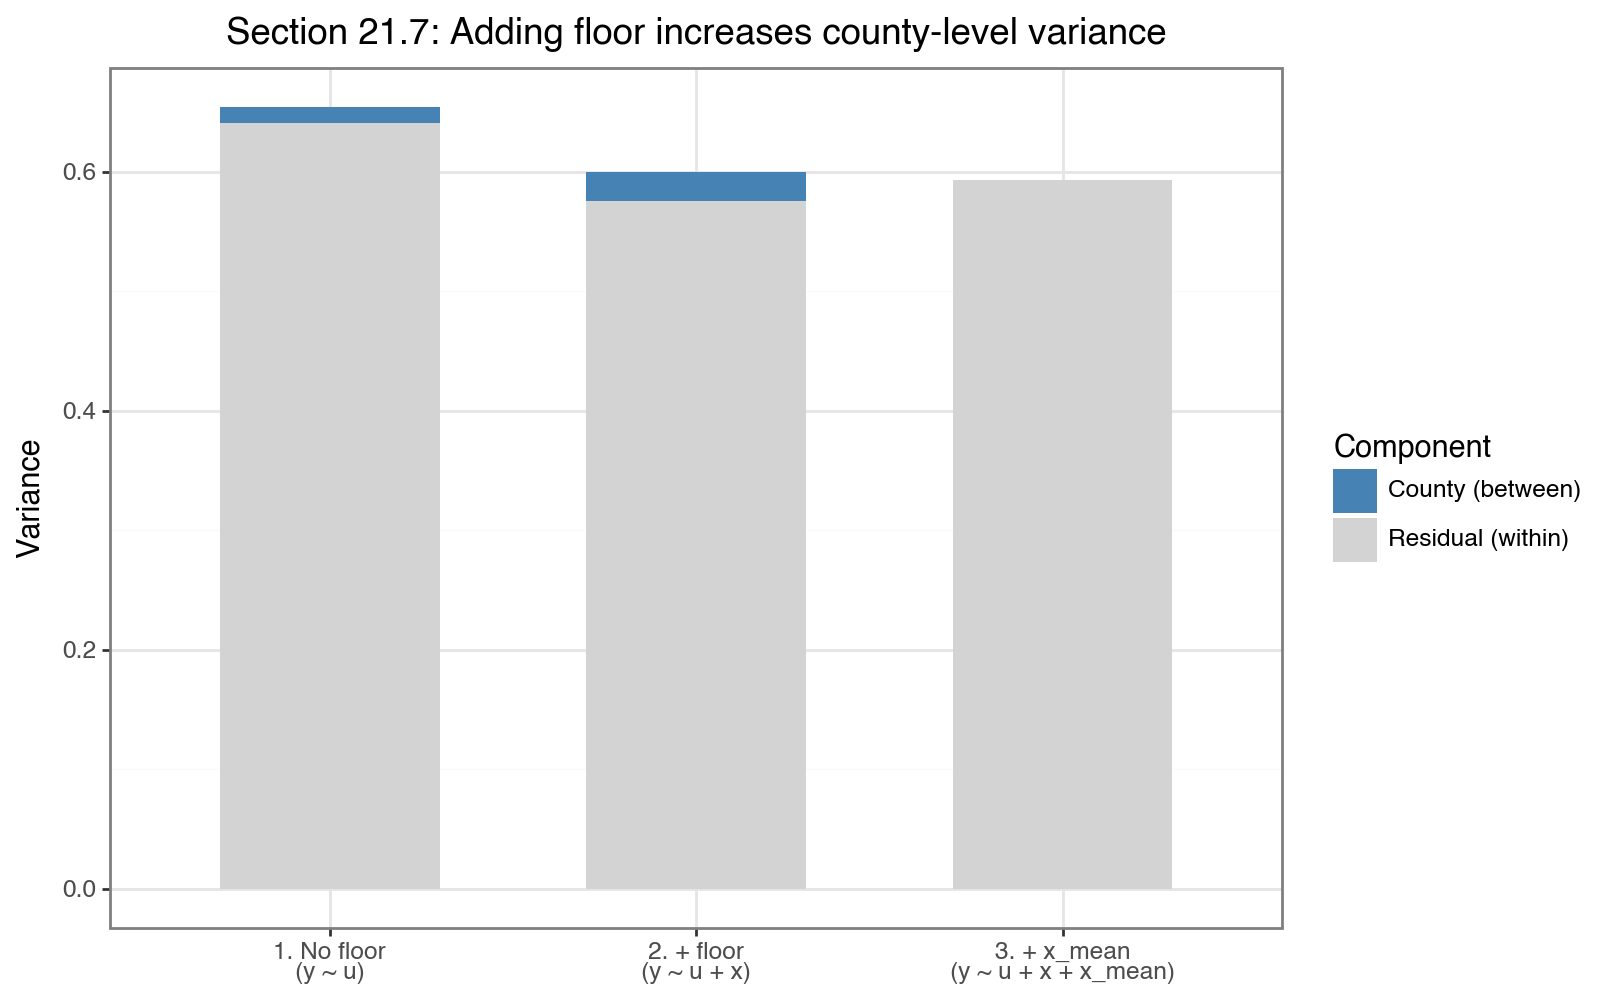

In [6]:
# Visualize: variance components across models
vc_rows = []
for label, model in [("1. No floor\n(y ~ u)", M_nox),
                     ("2. + floor\n(y ~ u + x)", M_floor),
                     ("3. + x_mean\n(y ~ u + x + x_mean)", M_xbar)]:
    vc_rows.append({"model": label, "component": "sigma2_county",
                    "value": model.variance_components["county"]})
    vc_rows.append({"model": label, "component": "sigma2_residual",
                    "value": model.scale})
vc_df = pd.DataFrame(vc_rows)
vc_df["model"] = pd.Categorical(vc_df["model"],
    categories=["1. No floor\n(y ~ u)", "2. + floor\n(y ~ u + x)",
                "3. + x_mean\n(y ~ u + x + x_mean)"], ordered=True)

(
    ggplot(vc_df, aes(x="model", y="value", fill="component"))
    + geom_col(position="stack", width=0.6)
    + scale_fill_manual(values=["steelblue", "lightgrey"],
                       labels=["County (between)", "Residual (within)"])
    + labs(
        x="", y="Variance",
        title="Section 21.7: Adding floor increases county-level variance",
        fill="Component",
    )
    + theme_bw()
    + theme(figure_size=(8, 5))
)

## 3. R-squared for multilevel models (Section 21.5)

In a multilevel model there is no single R-squared. We can compute:

1. **Individual-level R-squared**: how much of $\text{Var}(y)$ is explained
   by the full model (fixed effects + random effects)?
2. **Group-level R-squared**: how much of $\text{Var}(\bar{y}_j)$ is
   explained by the group-level component of the model?
3. **Marginal R-squared** ($R^2_m$): variance explained by fixed effects only
4. **Conditional R-squared** ($R^2_c$): variance explained by fixed + random effects

In [7]:
# R-squared computations for M_floor (the main model from Ch 12)
y = radon_df["y"].values
var_y = np.var(y)

print("=== R-squared for M_floor: y ~ u + x + (1|county) ===")
print()

# 1. Individual-level: 1 - Var(residuals) / Var(y)
resid = y - M_floor.fittedvalues
r2_individual = 1 - np.var(resid) / var_y
print(f"Individual-level R2: {r2_individual:.3f}")
print(f"  1 - Var(residuals)/Var(y) = 1 - {np.var(resid):.4f}/{var_y:.4f}")
print()

# 2. Nakagawa-Schielzeth marginal and conditional R-squared
# R2_m = Var(fixed) / (Var(fixed) + sigma2_county + sigma2_y)
# R2_c = (Var(fixed) + sigma2_county) / (Var(fixed) + sigma2_county + sigma2_y)
X = np.column_stack([
    np.ones(len(radon_df)),
    radon_df["u"].values,
    radon_df["x"].values,
])
beta = np.array([M_floor.fe_params["Intercept"], M_floor.fe_params["u"], M_floor.fe_params["x"]])
var_fixed = np.var(X @ beta)
sigma2_county = M_floor.variance_components["county"]
sigma2_y = M_floor.scale

r2_marginal = var_fixed / (var_fixed + sigma2_county + sigma2_y)
r2_conditional = (var_fixed + sigma2_county) / (var_fixed + sigma2_county + sigma2_y)

print(f"Nakagawa-Schielzeth R2:")
print(f"  Var(fixed)   = {var_fixed:.4f}")
print(f"  sigma2_county = {sigma2_county:.4f}")
print(f"  sigma2_y      = {sigma2_y:.4f}")
print(f"  R2_marginal   = {r2_marginal:.3f} (fixed effects only)")
print(f"  R2_conditional = {r2_conditional:.3f} (fixed + random effects)")
print()

# Compare across models
print("R-squared comparison across models:")
print(f"{'Model':<30} {'R2_m':>8} {'R2_c':>8}")
print("-" * 48)
for label, model, fe_names in [
    ("M_nox (y ~ u)", M_nox, ["Intercept", "u"]),
    ("M_floor (y ~ u + x)", M_floor, ["Intercept", "u", "x"]),
    ("M_xbar (y ~ u + x + x_mean)", M_xbar, ["Intercept", "u", "x", "x_mean"]),
]:
    cols = [np.ones(len(radon_df))]
    for fn in fe_names[1:]:
        cols.append(radon_df[fn].values)
    Xm = np.column_stack(cols)
    bm = np.array([model.fe_params[fn] for fn in fe_names])
    vf = np.var(Xm @ bm)
    vc = model.variance_components["county"]
    vr = model.scale
    rm = vf / (vf + vc + vr)
    rc = (vf + vc) / (vf + vc + vr)
    print(f"{label:<30} {rm:>8.3f} {rc:>8.3f}")

=== R-squared for M_floor: y ~ u + x + (1|county) ===

Individual-level R2: 0.228
  1 - Var(residuals)/Var(y) = 1 - 0.5613/0.7274

Nakagawa-Schielzeth R2:
  Var(fixed)   = 0.1256
  sigma2_county = 0.0245
  sigma2_y      = 0.5752
  R2_marginal   = 0.173 (fixed effects only)
  R2_conditional = 0.207 (fixed + random effects)

R-squared comparison across models:
Model                              R2_m     R2_c
------------------------------------------------
M_nox (y ~ u)                     0.095    0.115
M_floor (y ~ u + x)               0.173    0.207
M_xbar (y ~ u + x + x_mean)       0.188    0.188


## 4. Pooling factors (Section 21.6)

The **pooling factor** $\omega_j$ measures how much county $j$'s estimate
is shrunk toward the grand mean:

$$\omega_j = 1 - \frac{\text{Var}(\hat{\alpha}_j | y)}{\text{Var}(\hat{\alpha}_j^{\text{no-pool}})} = \frac{\sigma_y^2 / n_j}{\sigma_y^2 / n_j + \sigma_\alpha^2}$$

- $\omega_j = 0$: no pooling (large county, estimate based on own data)
- $\omega_j = 1$: complete pooling (tiny county, estimate = grand mean)

The **summary pooling factor** averages across counties:
$$\bar{\omega} = \frac{1}{J} \sum_{j=1}^J \omega_j$$

In [8]:
# Compute pooling factors for M_floor
sigma2_alpha = M_floor.variance_components["county"]
sigma2_y = M_floor.scale

county_n = radon_df.groupby("county").size()
omega = (sigma2_y / county_n) / (sigma2_y / county_n + sigma2_alpha)

pooling_df = pd.DataFrame({
    "county": county_n.index,
    "n": county_n.values,
    "omega": omega.values,
})

print("Pooling factors for M_floor (y ~ u + x + (1|county)):")
print(f"  sigma2_county = {sigma2_alpha:.4f}")
print(f"  sigma2_y      = {sigma2_y:.4f}")
print()
print(f"  Summary pooling factor (mean): {omega.mean():.3f}")
print(f"  Range: [{omega.min():.3f}, {omega.max():.3f}]")
print()

# Show extremes
print("Most pooled (smallest counties):")
top5 = pooling_df.nlargest(5, "omega")
for _, row in top5.iterrows():
    print(f"  County {int(row['county']):>2} (n={int(row['n']):>3}): omega = {row['omega']:.3f}")

print()
print("Least pooled (largest counties):")
bot5 = pooling_df.nsmallest(5, "omega")
for _, row in bot5.iterrows():
    print(f"  County {int(row['county']):>2} (n={int(row['n']):>3}): omega = {row['omega']:.3f}")

Pooling factors for M_floor (y ~ u + x + (1|county)):
  sigma2_county = 0.0245
  sigma2_y      = 0.5752

  Summary pooling factor (mean): 0.766
  Range: [0.169, 0.959]

Most pooled (smallest counties):
  County 42 (n=  1): omega = 0.959
  County 50 (n=  1): omega = 0.959
  County 82 (n=  1): omega = 0.959
  County 16 (n=  2): omega = 0.922
  County 23 (n=  2): omega = 0.922

Least pooled (largest counties):
  County 70 (n=116): omega = 0.169
  County 26 (n=105): omega = 0.183
  County 19 (n= 63): omega = 0.272
  County  2 (n= 52): omega = 0.311
  County 80 (n= 46): omega = 0.338


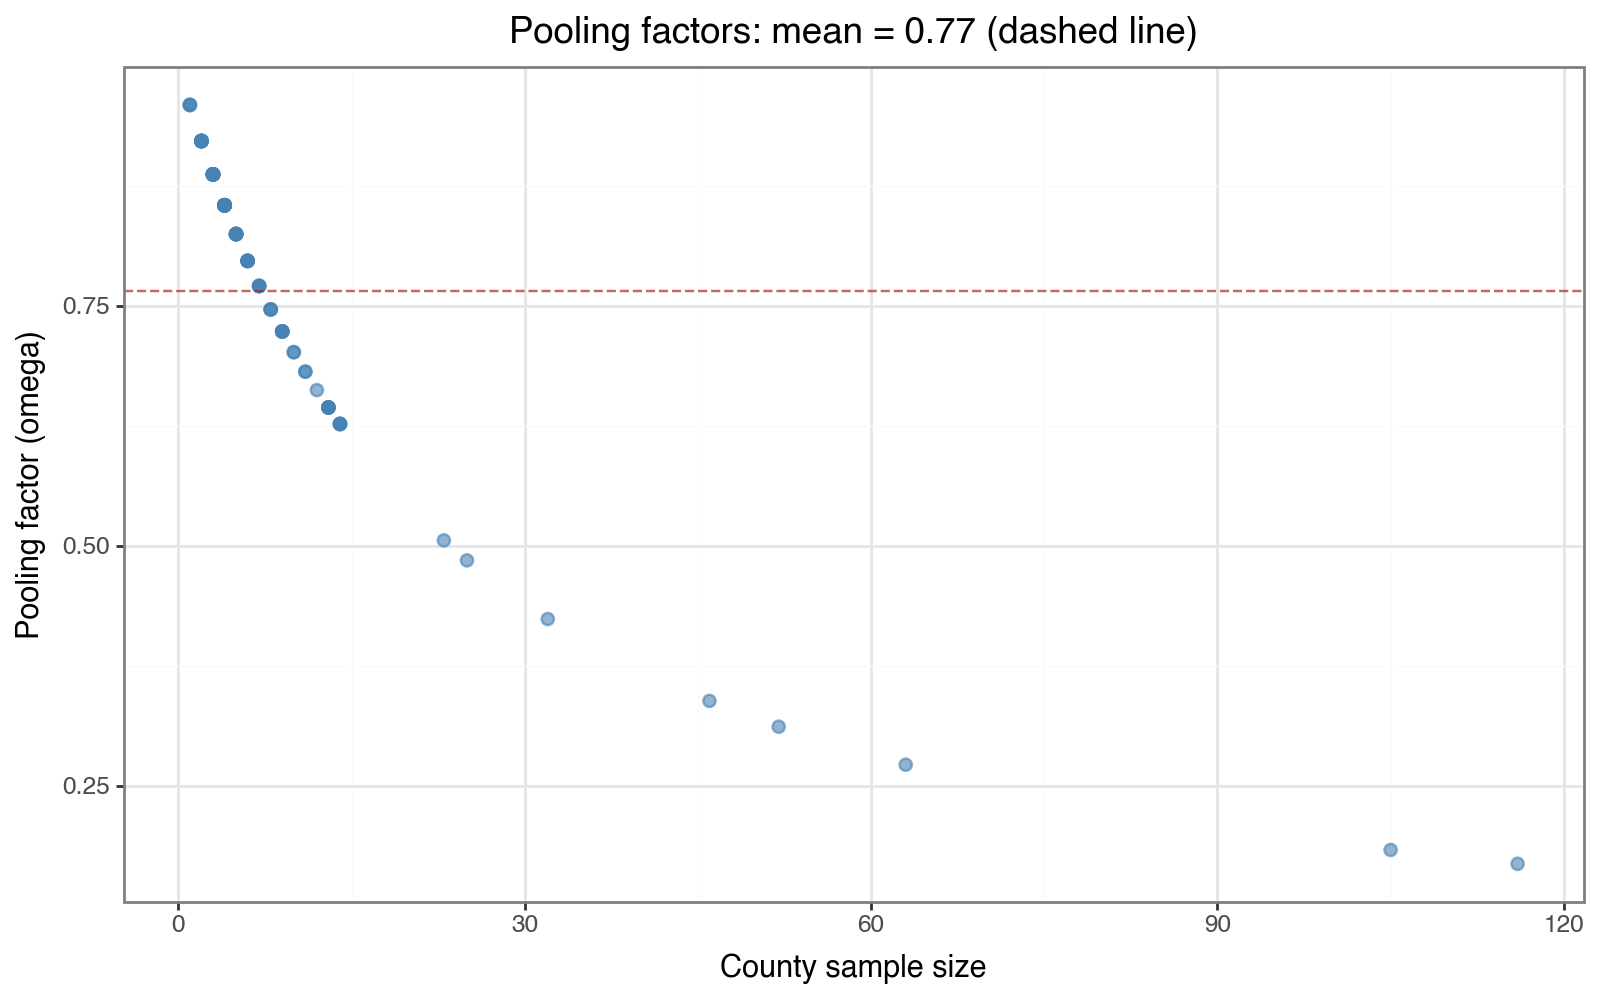

In [9]:
# Plot pooling factor vs sample size
(
    ggplot(pooling_df, aes(x="n", y="omega"))
    + geom_point(size=2, alpha=0.6, color="steelblue")
    + geom_hline(yintercept=omega.mean(), linetype="dashed", color="firebrick", alpha=0.7)
    + labs(
        x="County sample size",
        y="Pooling factor (omega)",
        title=f"Pooling factors: mean = {omega.mean():.2f} (dashed line)",
    )
    + theme_bw()
    + theme(figure_size=(8, 5))
)

---

## Summary

Key concepts from Chapter 21 demonstrated with interlace:

1. **Adding a predictor can increase group-level variance** (Section 21.7).
   Adding floor to the radon model increases $\sigma_\alpha$ from 0.12 to
   0.16 because floor is confounded with county — controlling for it
   reveals more true between-county variation.

2. **R-squared has multiple definitions** in multilevel models (Section 21.5).
   Marginal $R^2$ (fixed effects only) vs conditional $R^2$ (fixed + random)
   tell different stories about model fit.

3. **Pooling factors** quantify partial pooling (Section 21.6). Small counties
   ($n=1$) have $\omega \approx 0.96$ (nearly complete pooling), while large
   counties ($n=116$) have $\omega \approx 0.17$ (mostly own data).

4. **interlace matches R lme4** for all three models to tight numerical
   tolerances (~1e-8 for fixed effects, ~1e-8 for variance components).

Previous: [Chapter 17](ch17_varying_slopes_bugs.ipynb) | [Chapter 22](ch22_anova_as_multilevel.ipynb)